In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)
    

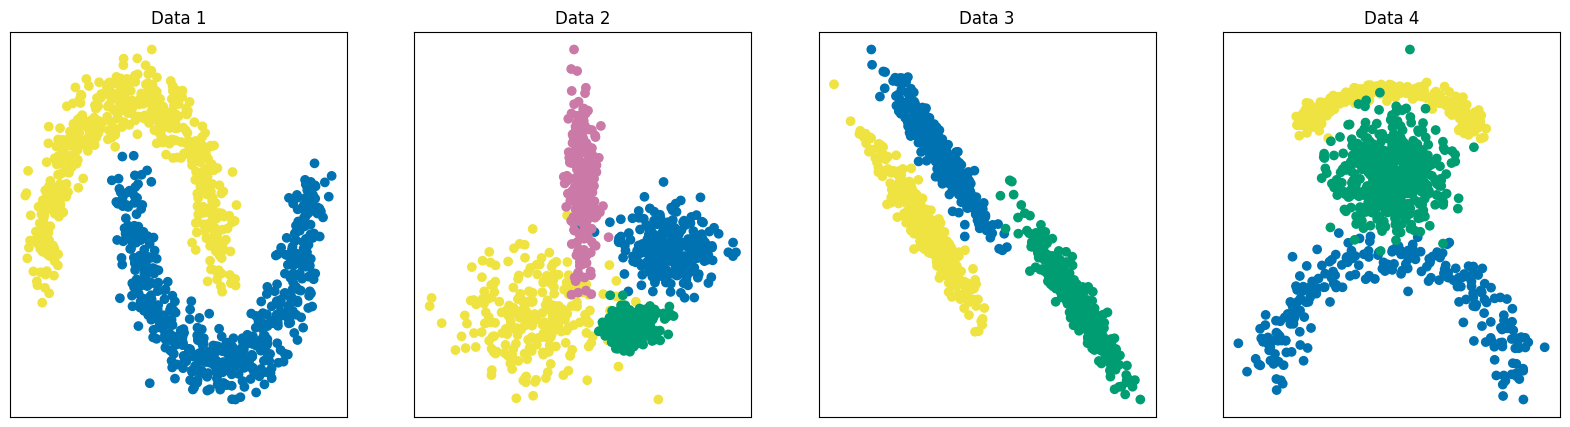

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [6]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1342.2076416015625 | Validation Loss: 2025.5924072265625
Iteration 99 | Train Loss: 268.3125915527344 | Validation Loss: 272.56793212890625
Iteration 199 | Train Loss: 235.20486450195312 | Validation Loss: 236.6018829345703
Iteration 299 | Train Loss: 207.6096649169922 | Validation Loss: 215.37294006347656
Iteration 399 | Train Loss: 222.4375457763672 | Validation Loss: 215.54429626464844
Iteration 499 | Train Loss: 206.63975524902344 | Validation Loss: 212.76446533203125
Iteration 599 | Train Loss: 207.49136352539062 | Validation Loss: 223.27920532226562
Iteration 699 | Train Loss: 199.1879425048828 | Validation Loss: 210.99929809570312
Iteration 799 | Train Loss: 192.00994873046875 | Validation Loss: 207.0786590576172
Iteration 899 | Train Loss: 188.27561950683594 | Validation Loss: 203.31980895996094
Iteration 999 | Train Loss: 186.03135681152344 | Validation Loss: 203.57974243164062
Iteration 1099 | Train Loss: 185.42442321777344 | Validation Loss: 203.300

In [7]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1327.651611328125 | Validation Loss: 2186.5849609375
Iteration 99 | Train Loss: 267.022705078125 | Validation Loss: 273.07208251953125
Iteration 199 | Train Loss: 210.96058654785156 | Validation Loss: 220.29214477539062
Iteration 299 | Train Loss: 201.4456787109375 | Validation Loss: 211.79100036621094
Iteration 399 | Train Loss: 196.74708557128906 | Validation Loss: 208.2424774169922
Iteration 499 | Train Loss: 197.79153442382812 | Validation Loss: 209.6942596435547
Iteration 599 | Train Loss: 196.94216918945312 | Validation Loss: 213.42506408691406
Iteration 699 | Train Loss: 194.83631896972656 | Validation Loss: 213.7969512939453
Iteration 799 | Train Loss: 194.2167205810547 | Validation Loss: 214.6855926513672
Iteration 899 | Train Loss: 193.03431701660156 | Validation Loss: 214.1369171142578
Early stopping at iteration 899


In [8]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1214.520751953125 | Validation Loss: 1628.3690185546875
Iteration 99 | Train Loss: 205.15480041503906 | Validation Loss: 199.06112670898438
Iteration 199 | Train Loss: 166.21556091308594 | Validation Loss: 167.74449157714844
Iteration 299 | Train Loss: 149.04623413085938 | Validation Loss: 155.93325805664062
Iteration 399 | Train Loss: 140.4486846923828 | Validation Loss: 146.26219177246094
Iteration 499 | Train Loss: 128.27699279785156 | Validation Loss: 132.4961700439453
Iteration 599 | Train Loss: 125.57234191894531 | Validation Loss: 131.64321899414062
Iteration 699 | Train Loss: 122.77936553955078 | Validation Loss: 126.20462799072266
Iteration 799 | Train Loss: 122.79810333251953 | Validation Loss: 127.1192855834961
Iteration 899 | Train Loss: 121.87706756591797 | Validation Loss: 124.85607147216797
Iteration 999 | Train Loss: 122.95708465576172 | Validation Loss: 129.0618133544922
Iteration 1099 | Train Loss: 121.79536437988281 | Validation Loss: 123.64

In [9]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1213.92431640625 | Validation Loss: 1677.775634765625
Iteration 99 | Train Loss: 258.3974304199219 | Validation Loss: 263.31219482421875
Iteration 199 | Train Loss: 220.19113159179688 | Validation Loss: 239.6480712890625
Iteration 299 | Train Loss: 212.1027069091797 | Validation Loss: 219.35813903808594
Iteration 399 | Train Loss: 202.83204650878906 | Validation Loss: 218.40821838378906
Iteration 499 | Train Loss: 201.44635009765625 | Validation Loss: 219.51266479492188
Iteration 599 | Train Loss: 198.4424285888672 | Validation Loss: 213.87588500976562
Iteration 699 | Train Loss: 199.13304138183594 | Validation Loss: 217.26881408691406
Iteration 799 | Train Loss: 197.802490234375 | Validation Loss: 213.4630126953125
Iteration 899 | Train Loss: 196.82310485839844 | Validation Loss: 212.09747314453125
Iteration 999 | Train Loss: 213.51119995117188 | Validation Loss: 245.63987731933594
Iteration 1099 | Train Loss: 211.370849609375 | Validation Loss: 232.631912231

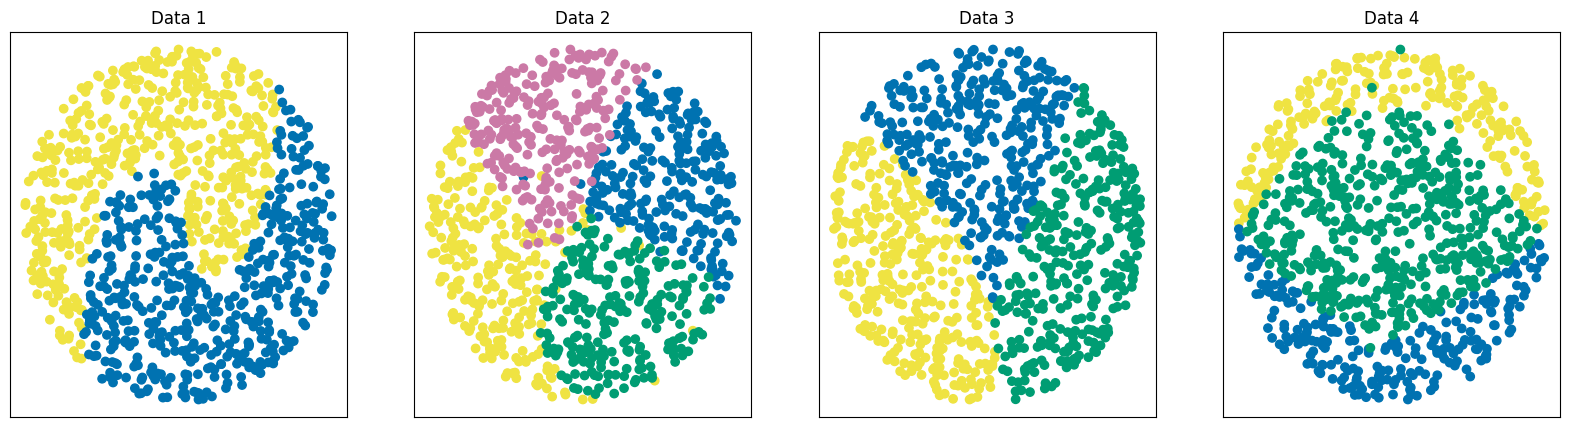

In [10]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c=[colour['y'] for _ in range(data_pushed[data[1] == 0].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c=[colour['b'] for _ in range(data_pushed[data[1] == 1].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c=[colour['g'] for _ in range(data_pushed[data[1] == 2].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 3, 0], data_pushed[data[1] == 3, 1], c=[colour['p'] for _ in range(data_pushed[data[1] == 3].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 4, 0], data_pushed[data[1] == 4, 1], c=[colour['lb'] for _ in range(data_pushed[data[1] == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [29]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        if np.all(new_medoids == medoids):
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=100):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        
        dists = dists[idx < n].reshape(k, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix, _ = LAMINAR.utils.dijkstra.dijkstra(LAM.graph, cluster_points.cpu().numpy(), cluster_points.cpu().numpy())
            
            distance_matrix = np.array(distance_matrix, dtype=np.float32)

            # only take rows and columns where cluster_points is True
            #distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            #print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [30]:
# do clustering for all datasets with euclidean metric

medoids1_euc, labels1_euc = k_medoids(data1[0], 2)
medoids2_euc, labels2_euc = k_medoids(data2[0], 4)
medoids3_euc, labels3_euc = k_medoids(data3[0], 3)
medoids4_euc, labels4_euc = k_medoids(data4[0], 3)

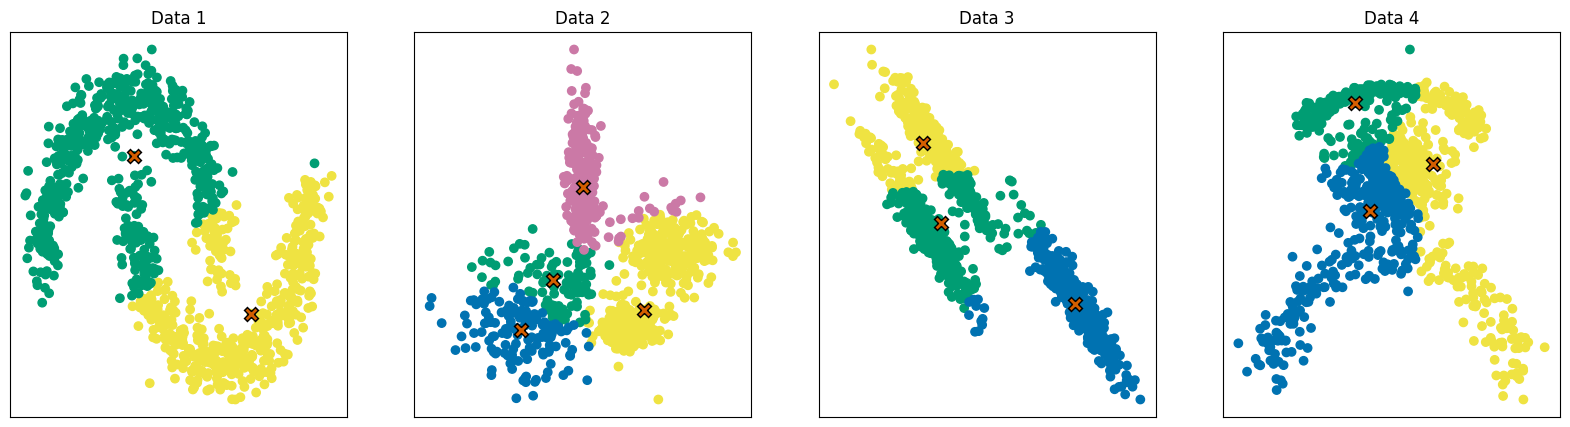

In [31]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_euc, medoids1_euc), (data2[0], labels2_euc, medoids2_euc), (data3[0], labels3_euc, medoids3_euc), (data4[0], labels4_euc, medoids4_euc)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [32]:
# same with LAM

medoids1_lam, labels1_lam = k_medoids_LAM(data1[0], 2, LAM1)
medoids2_lam, labels2_lam = k_medoids_LAM(data2[0], 4, LAM2)
medoids3_lam, labels3_lam = k_medoids_LAM(data3[0], 3, LAM3)
medoids4_lam, labels4_lam = k_medoids_LAM(data4[0], 3, LAM4)

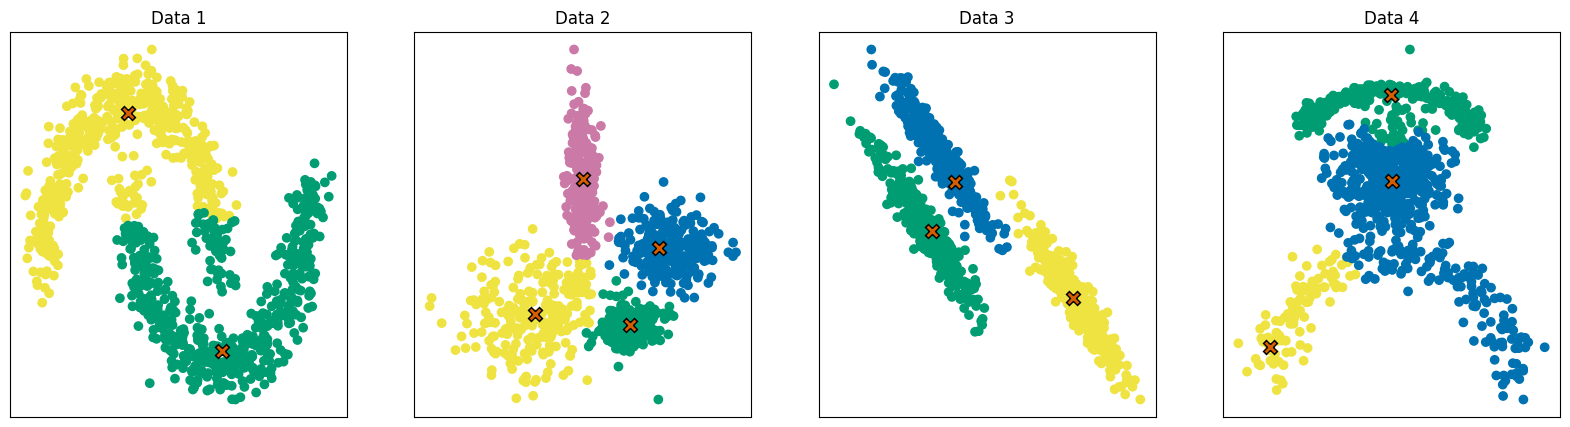

In [33]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_lam, medoids1_lam), (data2[0], labels2_lam, medoids2_lam), (data3[0], labels3_lam, medoids3_lam), (data4[0], labels4_lam, medoids4_lam)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [34]:
def jaccard(points1, points2):
    n = len(points1)
    m = len(points2)
    intersection = len(set(points1.numpy()).intersection(set(points2.numpy())))

    if m + n - intersection == 0:
        return np.round(0.0, 2)
    else:
        return np.round(intersection / (n + m - intersection), 2)

In [35]:
# calculate jaccard index for all datasets

for i, d, euc_lab, lam_lab in zip([0, 1, 2, 3], [data1, data2, data3, data4], [labels1_euc, labels2_euc, labels3_euc, labels4_euc], [labels1_lam, labels2_lam, labels3_lam, labels4_lam]):
    print('Data ', i+1)
    print('\n')
    
    # get indices of the points with certain labels
    gt_idx_1 = torch.where(d[1] == 0)[0]
    gt_idx_2 = torch.where(d[1] == 1)[0]
    gt_idx_3 = torch.where(d[1] == 2)[0]
    gt_idx_4 = torch.where(d[1] == 3)[0]

    # get indices of the points with certain labels
    euclidean_idx_1 = torch.where(torch.tensor(euc_lab) == 0)[0]
    euclidean_idx_2 = torch.where(torch.tensor(euc_lab) == 1)[0]
    euclidean_idx_3 = torch.where(torch.tensor(euc_lab) == 2)[0]
    euclidean_idx_4 = torch.where(torch.tensor(euc_lab) == 3)[0]

    # sma for lam
    lam_idx_1 = torch.where(lam_lab == 0)[0]
    lam_idx_2 = torch.where(lam_lab == 1)[0]
    lam_idx_3 = torch.where(lam_lab == 2)[0]
    lam_idx_4 = torch.where(lam_lab == 3)[0]

    print('Euclidean')
    print(jaccard(gt_idx_1, euclidean_idx_1), jaccard(gt_idx_2, euclidean_idx_1), jaccard(gt_idx_3, euclidean_idx_1), jaccard(gt_idx_4, euclidean_idx_1))
    print(jaccard(gt_idx_1, euclidean_idx_2), jaccard(gt_idx_2, euclidean_idx_2), jaccard(gt_idx_3, euclidean_idx_2), jaccard(gt_idx_4, euclidean_idx_2))
    print(jaccard(gt_idx_1, euclidean_idx_3), jaccard(gt_idx_2, euclidean_idx_3), jaccard(gt_idx_3, euclidean_idx_3), jaccard(gt_idx_4, euclidean_idx_3))   
    print(jaccard(gt_idx_1, euclidean_idx_4), jaccard(gt_idx_2, euclidean_idx_4), jaccard(gt_idx_3, euclidean_idx_4), jaccard(gt_idx_4, euclidean_idx_4))

    print('\n')

    print('LAM')
    print(jaccard(gt_idx_1, lam_idx_1), jaccard(gt_idx_2, lam_idx_1), jaccard(gt_idx_3, lam_idx_1), jaccard(gt_idx_4, lam_idx_1))
    print(jaccard(gt_idx_1, lam_idx_2), jaccard(gt_idx_2, lam_idx_2), jaccard(gt_idx_3, lam_idx_2), jaccard(gt_idx_4, lam_idx_2))
    print(jaccard(gt_idx_1, lam_idx_3), jaccard(gt_idx_2, lam_idx_3), jaccard(gt_idx_3, lam_idx_3), jaccard(gt_idx_4, lam_idx_3))
    print(jaccard(gt_idx_1, lam_idx_4), jaccard(gt_idx_2, lam_idx_4), jaccard(gt_idx_3, lam_idx_4), jaccard(gt_idx_4, lam_idx_4))

    print('\n')



    

Data  1


Euclidean
0.07 0.72 0.0 0.0
0.74 0.1 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


LAM
0.84 0.03 0.0 0.0
0.06 0.85 0.0 0.0
0.0 0.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  2


Euclidean
0.03 0.44 0.5 0.0
0.3 0.0 0.0 0.07
0.59 0.0 0.0 0.0
0.0 0.04 0.0 0.83


LAM
0.86 0.0 0.0 0.03
0.04 0.0 0.93 0.0
0.0 0.98 0.0 0.0
0.0 0.01 0.0 0.92


Data  3


Euclidean
0.11 0.58 0.0 0.0
0.57 0.17 0.02 0.0
0.02 0.0 0.92 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.0 1.0 0.0
1.0 0.0 0.0 0.0
0.0 1.0 0.0 0.0
0.0 0.0 0.0 0.0


Data  4


Euclidean
0.19 0.19 0.28 0.0
0.46 0.0 0.09 0.0
0.0 0.3 0.38 0.0
0.0 0.0 0.0 0.0


LAM
0.0 0.38 0.0 0.0
0.85 0.0 0.06 0.0
0.0 0.22 0.7 0.0
0.0 0.0 0.0 0.0


